# Telco Customer Churn Analysis

**Company:** ABC Communications Ltd  
**Consulting Team:** AnalystLab Africa Consulting  
**Role:** Junior Data Analyst

## 1. Business Understanding

### Business Problem

Customer churn occurs when customers discontinue their relationship with a company. In the telecommunications industry, churn is an important business concern because customers can switch between competing providers, making customer retention an ongoing challenge. Research on telecommunications churn shows that factors such as contract conditions, tenure, billing, payment behaviour, service characteristics, and customer-related factors can be associated with a customer's likelihood of leaving.

ABC Communications Ltd has engaged AnalystLab Africa Consulting to investigate customer churn and identify patterns within its customer base. The purpose of this analysis is to understand which customer groups have higher churn levels and which aspects of the customer relationship may be associated with retention or customer loss.

### Business Objective

The objective of this project is to analyze the Telco Customer Churn dataset and generate business insights that can help ABC Communications Ltd develop more effective customer retention strategies.

The analysis will examine the characteristics of the customer base and investigate whether churn varies according to customer segments, contract type, tenure, subscribed services, and payment methods. The findings will then be translated into practical recommendations that management can use to reduce customer churn and strengthen customer retention.

### Key Business Questions

The analysis will address the following questions:

1. What does the customer base look like?
2. Which customer segments have the highest churn?
3. Does contract type influence retention?
4. Does tenure affect customer loyalty?
5. Which services are associated with churn?
6. Which payment methods have higher churn?
7. What actions should management take based on the findings?

### Analytical Approach

The project will use exploratory and descriptive data analysis to examine customer characteristics and identify patterns in churn. The dataset will first be inspected for its structure, data types, missing values, duplicates, and summary statistics. After data preparation, visualizations and statistical summaries will be used to compare churn across relevant customer segments.

The analysis will focus particularly on contract type, tenure, services, and payment methods because these areas have been identified in telecommunications research as potentially relevant to customer churn. Previous research has found that customer seniority/tenure is frequently associated with churn, while tariff and billing characteristics can also influence churn behaviour.

### Expected Business Value

The analysis is expected to help ABC Communications Ltd identify customer groups that may require greater retention attention. Rather than treating all customers in the same way, the company can use the findings to prioritize retention efforts toward segments showing higher levels of churn.

The resulting insights can support decisions around customer engagement, contract strategies, service offerings, and payment options. Ultimately, the goal is to provide management with evidence-based recommendations that can help reduce avoidable customer losses, improve customer loyalty, and support sustainable business performance.


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading & Inspection

In [42]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [43]:
df.shape

(7043, 21)

In [44]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Data Cleaning

In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [48]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [12]:
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [49]:
df = df.dropna(subset=['TotalCharges'])

In [14]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## 4. Business Data Analysis

In [15]:
df['gender'].value_counts()

,count
gender,
Male,3549
Female,3483


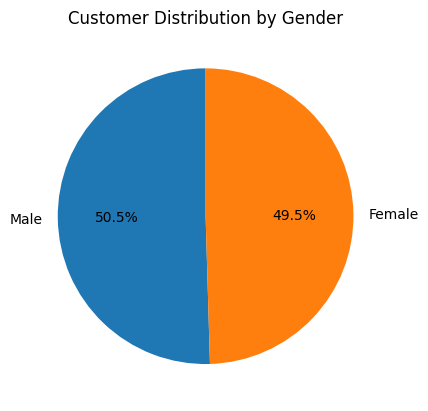

In [16]:
df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Distribution by Gender')
plt.ylabel('')
plt.show()

**Interpretation:** The customer base is almost evenly split by gender, with males representing 50.5% of customers and females representing 49.5%. This indicates that the company has a relatively balanced gender distribution, with no major gender imbalance in the overall customer base.

In [17]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1685
One year,1472


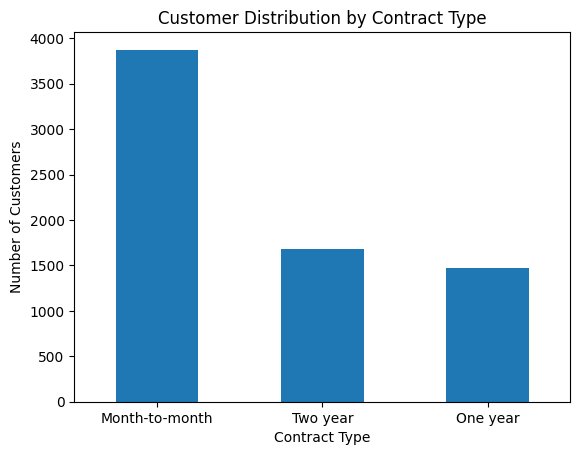

In [18]:
df['Contract'].value_counts().plot(kind='bar')

plt.title('Customer Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

**Interpretation:** The customer base is dominated by month-to-month contracts, with approximately 3,875 customers. One-year and two-year contracts have considerably fewer customers, with approximately 1,470 and 1,685 customers respectively. This indicates that a large proportion of the company's customers are on flexible, short-term contracts, which is important because month-to-month customers may represent a greater retention risk.

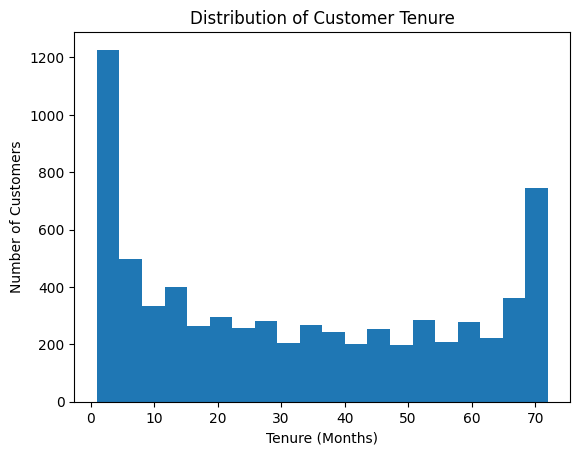

In [19]:
plt.hist(df['tenure'], bins=20)

plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

**Interpretation:** Customer tenure is unevenly distributed across the customer base. There is a particularly large concentration of customers with very short tenure, especially during the first few months. There is also a notable concentration of long-term customers toward the 70-month range, while customers with mid-range tenure are more evenly distributed. The large number of newer customers highlights the importance of early-stage customer retention.

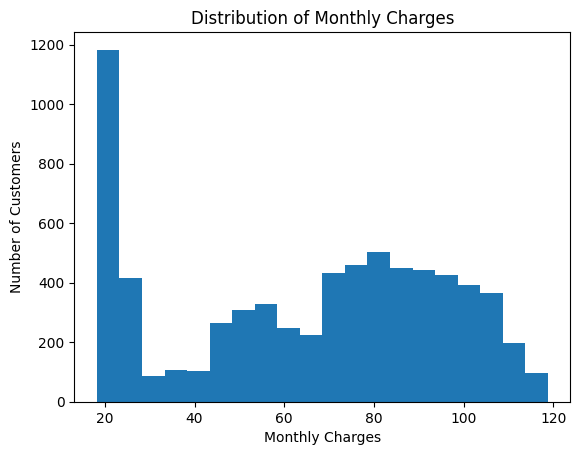

In [20]:
plt.hist(df['MonthlyCharges'], bins=20)

plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

**Interpretation:** Monthly charges vary considerably across the customer base. There is a large concentration of customers with relatively low monthly charges, particularly around 20, while a substantial number of customers have monthly charges between approximately 70 and 105. This indicates that the company serves customers across a broad range of pricing levels, with a notable concentration in the higher monthly-charge range.

In [21]:
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,5890
1,1142


In [50]:
senior_status = df['SeniorCitizen'].map({
    0: 'Not Senior Citizen',
    1: 'Senior Citizen'
})


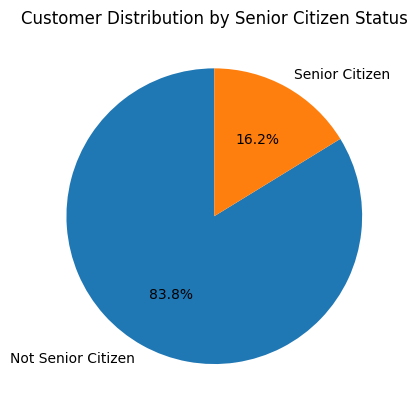

In [23]:

senior_status.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Distribution by Senior Citizen Status')
plt.ylabel('')
plt.show()

**Interpretation:** The customer base is predominantly made up of non-senior citizens, who represent 83.8% of customers. Senior citizens account for 16.2% of the customer base. This indicates that senior citizens represent a relatively small segment of the overall customer population.

In [24]:
pd.crosstab(
    df['gender'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


In [51]:
churn_by_gender = pd.crosstab(
    df['gender'],
    df['Churn'],
    normalize='index'
) * 100

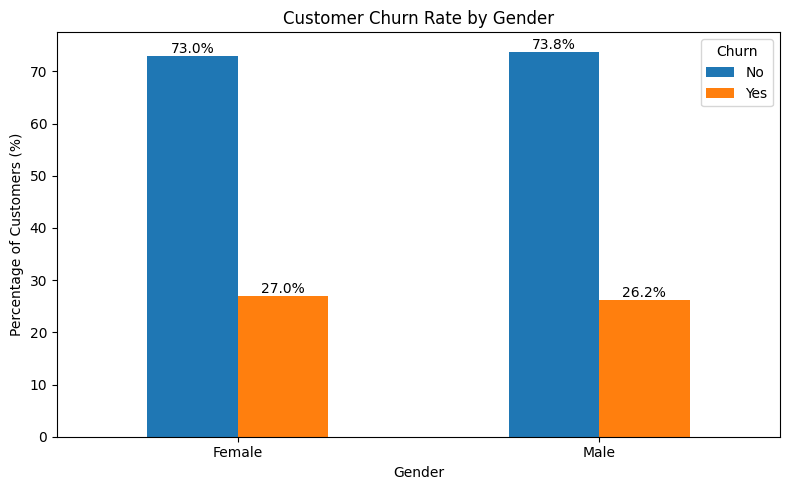

In [26]:
ax = churn_by_gender.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Customer Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage of Customers (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

**Interpretation:** Churn rates are very similar across genders. Female customers have a churn rate of 27.0%, while male customers have a churn rate of 26.2%. The small difference of 0.8 percentage points suggests that gender is not a major factor associated with customer churn.

In [27]:
churn_by_contract = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


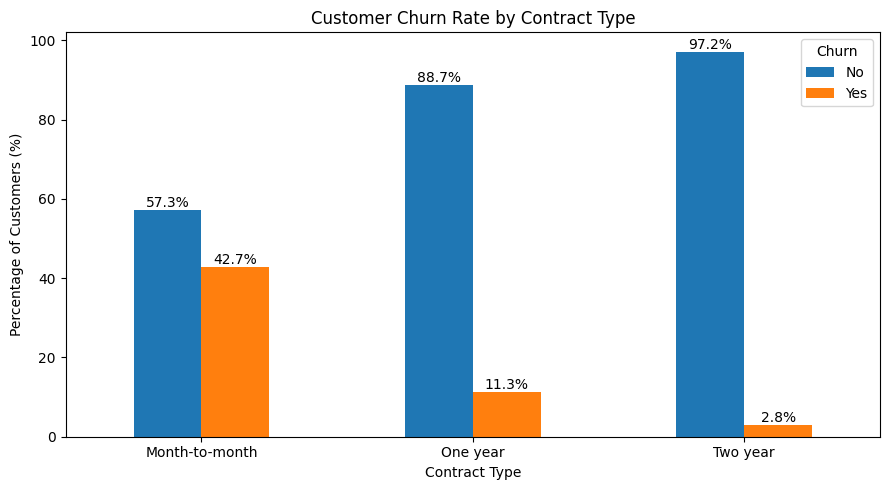

In [28]:
ax = churn_by_contract.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Customer Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage of Customers (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

**Interpretation:** Contract type shows a strong relationship with customer retention. Month-to-month customers have the highest churn rate at 42.7%, compared with 11.3% for one-year contracts and only 2.8% for two-year contracts. The substantial difference suggests that customers on longer-term contracts are considerably more likely to remain with the company, while month-to-month customers represent a high-risk churn segment.

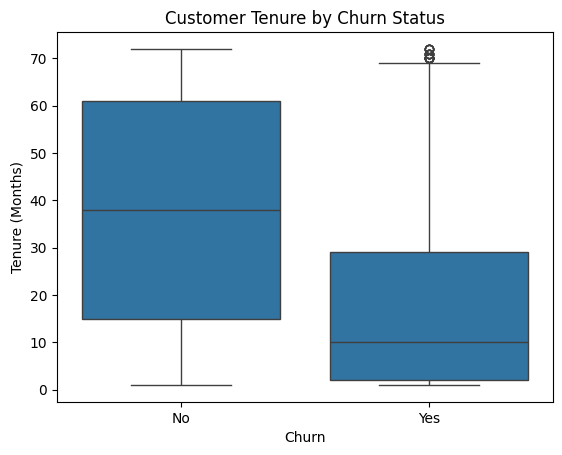

In [29]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

**Interpretation:** Tenure shows a clear relationship with customer churn. Customers who stayed with the company have a median tenure of approximately 38 months, while customers who churned have a median tenure of approximately 10 months. This indicates that newer customers are considerably more likely to churn than long-term customers, making early-stage customer retention an important area for management attention.

In [30]:
churn_by_internet = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_internet

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


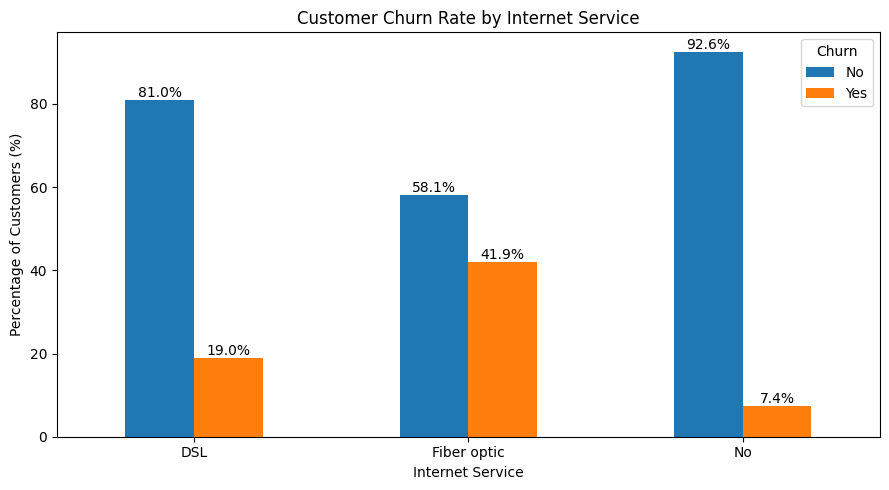

In [31]:
ax = churn_by_internet.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Customer Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Percentage of Customers (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

**Interpretation:** Churn varies substantially by internet service type. Fiber optic customers have the highest churn rate at 41.9%, compared with 19.0% for DSL customers and 7.4% for customers without internet service. This identifies fiber optic customers as a high-risk segment and suggests that management should investigate the factors contributing to the higher churn among these customers.

In [32]:
security_churn = pd.crosstab(
    df['OnlineSecurity'],
    df['Churn'],
    normalize='index'
) * 100

security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


In [33]:
support_churn = pd.crosstab(
    df['TechSupport'],
    df['Churn'],
    normalize='index'
) * 100

support_churn

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


In [34]:
churn_by_payment = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_payment

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


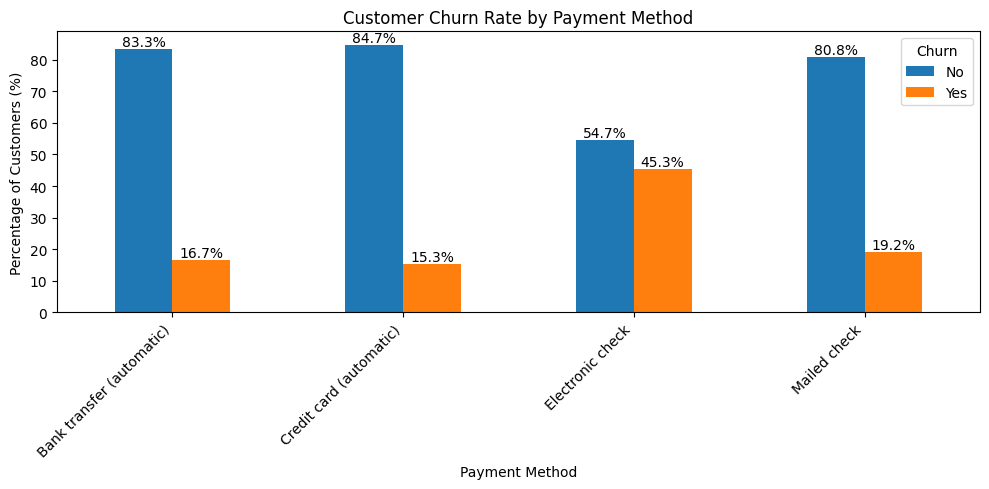

In [35]:
ax = churn_by_payment.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Customer Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Percentage of Customers (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

**Interpretation:** Churn varies considerably across payment methods. Customers using electronic checks have the highest churn rate at 45.3%, substantially higher than mailed checks at 19.2%, automatic bank transfers at 16.7%, and automatic credit card payments at 15.3%. This identifies electronic-check customers as a particularly high-risk segment and suggests that management should investigate whether payment experience or billing processes are contributing to higher churn.

In [36]:
df['Churn_numeric'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [37]:
df = df.copy()

In [38]:
df['Churn_numeric'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})


In [39]:
correlation = df[
    ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']
].corr()

correlation

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_numeric
SeniorCitizen,1.000000,0.015683,0.219874,0.102411,0.150541
tenure,0.015683,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.219874,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484
Churn_numeric,0.150541,-0.354049,0.192858,-0.199484,1.000000


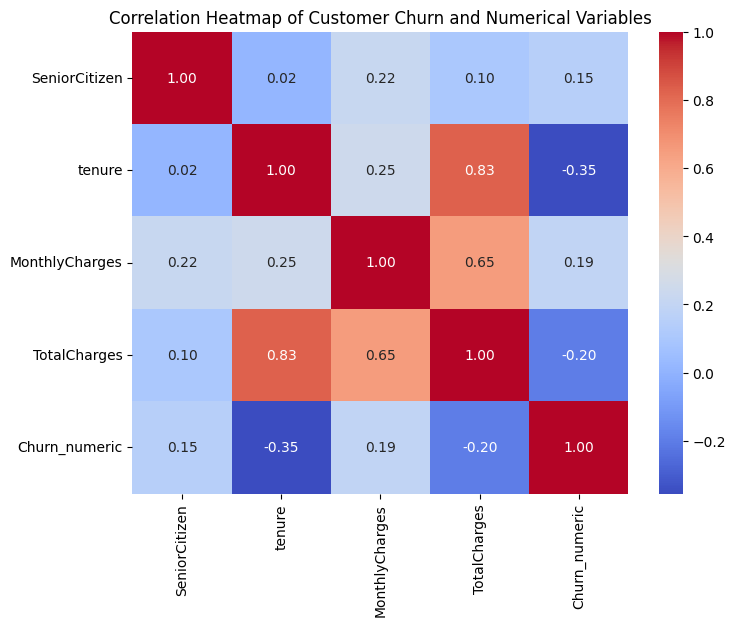

In [40]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Customer Churn and Numerical Variables')
plt.show()

**Interpretation:** Tenure has the strongest relationship with customer churn among the numerical variables, with a correlation of -0.35, indicating that customers with longer tenure tend to be less likely to churn. Total Charges also has a weak negative correlation with churn (-0.20), while Monthly Charges (0.19) and Senior Citizen status (0.15) have weak positive correlations with churn. Overall, the heatmap suggests that tenure has the most notable numerical relationship with customer churn.

## Business Insights

### Insight 1: Contract Type and Churn
Month-to-month customers have the highest churn rate at 42.7%, compared with 11.3% for one-year contracts and only 2.8% for two-year contracts. This indicates a strong association between contract type and customer retention.

### Insight 2: Tenure and Customer Loyalty
Churned customers have a median tenure of approximately 10 months, compared with approximately 38 months among customers who stayed. This indicates that newer customers are considerably more likely to churn.

### Insight 3: Fiber Optic Customers Are a High-Risk Segment
Fiber optic customers have a churn rate of 41.9%, compared with 19.0% for DSL customers and 7.4% for customers without internet service. This makes fiber optic customers an important segment for further investigation and retention efforts.

### Insight 4: Additional Services and Retention
Customers without Online Security have a churn rate of 41.8%, compared with 14.6% among customers with the service. A similar pattern exists for Tech Support, where customers without the service have a 41.6% churn rate compared with 15.2% among customers with the service.

### Insight 5: Electronic Check Customers Have the Highest Churn
Electronic check users have the highest churn rate at 45.3%, substantially higher than customers using mailed checks, automatic bank transfers, or automatic credit card payments. This identifies electronic-check customers as a high-risk segment.

## Business Risks

1. **High exposure to month-to-month customers:** A large proportion of customers are on month-to-month contracts, which have a 42.7% churn rate. Continued churn in this segment could negatively affect recurring revenue.

2. **Early customer attrition:** Newer customers are substantially more likely to churn than long-term customers. Losing customers early can reduce customer lifetime value and limit the return on customer acquisition efforts.

3. **Concentrated churn in specific segments:** Fiber optic customers and electronic-check users have particularly high churn rates. Persistent churn within these segments could create significant revenue and customer-retention challenges.

## Business Opportunities

1. **Promote longer-term contracts:** The substantially lower churn among one-year and two-year contract customers presents an opportunity to encourage suitable month-to-month customers to switch to longer-term plans through incentives, discounts, or added benefits.

2. **Strengthen early-stage customer retention:** Since newer customers show considerably higher churn, the company can introduce targeted onboarding and engagement programs during the first several months of the customer relationship.

3. **Improve value and support for high-risk service segments:** Fiber optic customers and customers without Online Security or Tech Support show high churn rates. The company can use targeted service reviews, support offers, and bundled packages to improve the perceived value of these services.


## Business Recommendations

1. **Create incentives for longer-term contracts:** Offer targeted discounts, loyalty benefits, or additional services to eligible month-to-month customers who switch to one-year or two-year contracts.

2. **Launch an early-tenure retention program:** Introduce proactive check-ins, onboarding support, satisfaction surveys, and targeted offers during the first 12 months of a customer's relationship with the company.

3. **Investigate fiber optic churn:** Conduct a deeper review of fiber optic customers to identify whether pricing, service quality, technical issues, or customer expectations are contributing to the 41.9% churn rate.

4. **Promote Online Security and Tech Support:** Consider bundling these services with internet plans or offering introductory incentives, as customers with these services show substantially lower churn rates.

5. **Review the electronic-check payment experience:** Investigate why electronic-check customers have a 45.3% churn rate and consider encouraging customers to adopt automatic bank transfer or credit card payment options where appropriate.

6. **Develop a churn-risk monitoring system:** Regularly identify customers with high-risk characteristics such as short tenure, month-to-month contracts, and high-risk service or payment combinations so that retention teams can intervene before customers leave.

## Conclusion

The analysis shows that customer churn at ABC Communications is concentrated within specific customer segments. Month-to-month customers have the highest churn rate at 42.7%, while customers on one-year and two-year contracts have much lower churn rates of 11.3% and 2.8%, respectively.

Customer tenure also has a strong relationship with churn, with churned customers having a much lower median tenure than customers who remain. Fiber optic customers, customers without Online Security or Tech Support, and electronic-check users also show substantially higher churn rates.

These findings suggest that ABC Communications should prioritize early-tenure customers and other high-risk segments through targeted retention strategies. Encouraging suitable customers to adopt longer-term contracts, improving the value of support and security services, investigating fiber optic customer experience, and reviewing the electronic-check payment experience could help reduce customer churn and improve long-term customer retention.